In [1]:
import oqupy
import oqupy.operators as op
import numpy as np
import matplotlib.pyplot as plt
import time

import numpy as np
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d
from scipy.optimize import minimize,Bounds

pt_parameters = {'tmax':50,
                 'steps':100, 
                 'dkmax':50,
                 'epsrel':10**(-6),
                 'alpha':0.1,
                 'omega_cutoff':1,                 
                 'temp':0.131}
"""
pt_parameters = {'tmax':5,
                 'steps':50, 
                 'dkmax':100,
                 'epsrel':10**(-4),
                 'alpha':1e-20,
                 'omega_cutoff':3.04,                 
                 'temp':0.131}"""



omega_cutoff = pt_parameters['omega_cutoff']
alpha = pt_parameters['alpha']
temperature = pt_parameters['temp']
epsrel = pt_parameters['epsrel']
t_max = pt_parameters['tmax']
# dt = 1./omega_cutoff/np.sqrt(3)
num_steps = pt_parameters['steps']
dt = t_max/num_steps
dkmax = pt_parameters['dkmax']

initial_state = op.spin_dm('x+')
target_state = op.spin_dm('x-')
target_derivative = target_state.T

t_list = np.linspace(0,t_max,num_steps+1)


In [2]:
import tensornetwork as tn
d = 2  # dimension of each leg
start_cap = np.zeros((d, d, d))
for i in range(d):
    start_cap[i, i, i] = 1.0

x=tn.Node(start_cap)
print(x.tensor.shape)


(2, 2, 2)


In [3]:
import oqupy as oqupy
from oqupy.iTEBD_TEMPO_useoqupybath import iTEBD_TEMPO_oqupy
from oqupy.process_tensor import TTInvariantProcessTensor
from oqupy.tti_tempo import TTITempo
import numpy as np
import matplotlib.pyplot as plt

#1
correlations = oqupy.PowerLawSD(alpha=alpha,
                                zeta=1,
                                cutoff=omega_cutoff,
                                cutoff_type='exponential',
                                temperature=temperature)
bath = oqupy.Bath(op.sigma("z")/2.0, correlations)
parameters=oqupy.TempoParameters(dt=dt,epsrel=epsrel,dkmax=dkmax)

pt=TTITempo(bath,start_time=0.0,parameters=parameters)
process_tensor_tebd = pt.get_process_tensor()

building influence functional:  44%|████▍     | 22/50 [00:00<00:00, 199.83it/s]

building influence functional: 100%|██████████| 50/50 [00:01<00:00, 45.27it/s] 

rank  142 (142, 4, 142)


--> Compute dynamics:
100.0%  100 of  100 [########################################] 00:00:04
Elapsed time: 4.9s


array([[ 0.4999885 -1.36099943e-14j, -0.48245057+1.60778787e-14j],
       [-0.48245057+1.02246146e-14j,  0.4999885 -1.63334563e-14j]])

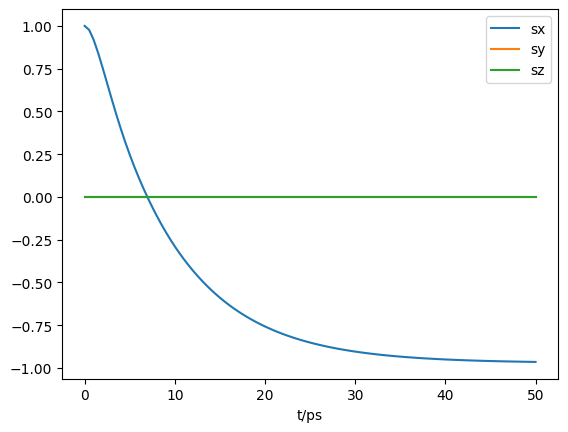

In [4]:
def hamiltonian_t(t):
    return pt_parameters['omega_cutoff']*op.sigma('x')/2

system_td = oqupy.TimeDependentSystem(hamiltonian_t)


Rho_0=oqupy.operators.spin_dm('x+')
#Rho_0=oqupy.operators.spin_dm('z-')

dynamics = oqupy.compute_dynamics(
       process_tensor=process_tensor_tebd,        
       system=system_td,
       initial_state=Rho_0,
       start_time=0,
       num_steps=num_steps)

t, s_x = dynamics.expectations(op.sigma('x'), real=True)
t,s_z = dynamics.expectations(op.sigma('z'), real=True)
t, s_y = dynamics.expectations(op.sigma('y'), real=True)

plt.plot(t,s_x,label='sx')
plt.plot(t,s_y,label='sy')
plt.plot(t,s_z,label='sz')
plt.xlabel('t/ps')
plt.legend()
dynamics.states[-1]


In [5]:
from oqupy.gate_gradient import compute_dynamical_map,compute_dynamical_map_and_grad
from oqupy.gradient import state_gradient

def discrete_hamiltonian(hx,hz):
    return hx*op.sigma('x')/2 + hz*op.sigma('z')/2
system = oqupy.ParameterizedSystem(discrete_hamiltonian)

h_z = np.ones(2*num_steps)*0
h_x = np.ones(2*num_steps)*omega_cutoff

parameters = np.vstack((h_x,h_z)).T
parameters.shape

gradient=state_gradient(system=system,
                        initial_state=initial_state,
                        target_derivative=op.spin_dm('x-').T,
                        process_tensors=[process_tensor_tebd],
                        parameters=parameters,
                        num_steps=num_steps)



--> Compute forward propagation:
100.0%  100 of  100 [########################################] 00:00:00
Elapsed time: 0.9s
--> Compute backward propagation:
100.0%  100 of  100 [########################################] 00:00:01
Elapsed time: 1.3s
--> Apply chain rule:
  0.0%    0 of  100 [----------------------------------------] 00:00:00(4, 4)
(4, 4)
(4, 4)
(4, 4)
  1.0%    1 of  100 [----------------------------------------] 00:00:00(4, 4)
(4, 4)
(4, 4)
(4, 4)
  2.0%    2 of  100 [----------------------------------------] 00:00:00(4, 4)
(4, 4)
(4, 4)
(4, 4)
  3.0%    3 of  100 [#---------------------------------------] 00:00:00(4, 4)
(4, 4)
(4, 4)
(4, 4)
  4.0%    4 of  100 [#---------------------------------------] 00:00:00(4, 4)
(4, 4)
(4, 4)
(4, 4)
  5.0%    5 of  100 [##--------------------------------------] 00:00:00(4, 4)
(4, 4)
(4, 4)
(4, 4)
  6.0%    6 of  100 [##--------------------------------------] 00:00:00(4, 4)
(4, 4)
(4, 4)
(4, 4)
  7.0%    7 of  100 [##-------------

In [21]:
map_list=compute_dynamical_map(system,
        [process_tensor_tebd],
        parameters,
        dt,
        start_time=0,
        num_steps=num_steps)

map_list,grad_list=compute_dynamical_map_and_grad(system,
        [process_tensor_tebd],
        parameters,
        dt,
        start_time=0,
        num_steps=num_steps)

 98.0%   98 of  100 [#######################################-] 00:09:19

In [ ]:

from oqupy.process_tensor import create_delta_lastindex
# for chain rule to work, need to add identity legs to beginning and end tensors

grad_for_chain_list = [g.copy() for g in grad_list]
grad_for_chain_list[-1]=create_delta_lastindex(grad_list[-1])


# need two for first one
grad_for_chain_list[0]=create_delta_lastindex(grad_list[0])
grad_for_chain_list[0]=create_delta_lastindex(grad_for_chain_list[0])
print(grad_list[0].shape)
print(grad_for_chain_list[-1].shape)
grad_for_chain_list[0]=np.transpose(grad_for_chain_list[0],[4,0,1,2,5,3])
# now will work with chain rule code ->

(4, 4, 4, 4)
(4, 4, 4, 4, 4)


 98.0%   98 of  100 [#######################################-] 00:10:16

In [ ]:
from oqupy.gate_gradient import gate_chain_rule

num_parameters = parameters.shape[1]

propagators=system.get_propagators(dt,parameters)
prop_derivs=system.get_propagator_derivatives(dt,parameters)

dyn_map_derivatives=gate_chain_rule(adjoint_tensor=grad_for_chain_list,propagators=propagators,dprop_dparam=prop_derivs,num_steps=num_steps,num_parameters=num_parameters)

--> Apply chain rule:
  0.0%    0 of  100 [----------------------------------------] 00:00:00!
(4, 4, 4, 4, 4, 4)
(4, 4)
!
(4, 4, 4, 4, 4, 4)
(4, 4)
!
(4, 4, 4, 4, 4, 4)
(4, 4)
!
(4, 4, 4, 4, 4, 4)
(4, 4)
  1.0%    1 of  100 [----------------------------------------] 00:00:00!
(4, 4, 4, 4, 4, 4)
(4, 4)
!
(4, 4, 4, 4, 4, 4)
(4, 4)
!
(4, 4, 4, 4, 4, 4)
(4, 4)
!
(4, 4, 4, 4, 4, 4)
(4, 4)
  2.0%    2 of  100 [----------------------------------------] 00:00:00!
(4, 4, 4, 4, 4, 4)
(4, 4)
!
(4, 4, 4, 4, 4, 4)
(4, 4)
!
(4, 4, 4, 4, 4, 4)
(4, 4)
!
(4, 4, 4, 4, 4, 4)
(4, 4)
  3.0%    3 of  100 [#---------------------------------------] 00:00:00!
(4, 4, 4, 4, 4, 4)
(4, 4)
!
(4, 4, 4, 4, 4, 4)
(4, 4)
!
(4, 4, 4, 4, 4, 4)
(4, 4)
!
(4, 4, 4, 4, 4, 4)
(4, 4)
  4.0%    4 of  100 [#---------------------------------------] 00:00:00!
(4, 4, 4, 4, 4, 4)
(4, 4)
!
(4, 4, 4, 4, 4, 4)
(4, 4)
!
(4, 4, 4, 4, 4, 4)
(4, 4)
!
(4, 4, 4, 4, 4, 4)
(4, 4)
  5.0%    5 of  100 [##--------------------------------------] 

  0.0%    0 of  100 [----------------------------------------] 00:01:16

In [ ]:
import numpy as npt
from scipy.optimize import approx_fprime

def func_jacobian(maps_list, func, eps=1e-8):
    """
    maps_list: list of 4x4 numpy arrays
    func: callable taking a list of 4x4 numpy arrays and returning scalar
    eps: finite difference step
    Returns:
        derivatives: list of 4x4 numpy arrays, df/dM_t for each timestep
    """
    derivatives = []
    
    for t, M in enumerate(maps_list):
        # flatten the matrix
        M_flat = M.flatten()
        
        # define a wrapper function that takes flattened M
        def f_flat(Mf):
            Mf_matrix = Mf.reshape(M.shape)
            maps_copy = maps_list.copy()
            maps_copy[t] = Mf_matrix
            return func(maps_copy)
        
        grad_flat = approx_fprime(M_flat, f_flat, epsilon=eps)
        grad_matrix = grad_flat.reshape(M.shape)
        derivatives.append(grad_matrix)
    
    return derivatives

def trace_distance_grad_maps(maps_list, target):
    grad_list = []
    for M in maps_list:
        X = M - target
        U, S, Vh = np.linalg.svd(X)
        grad = 0.5 * U @ Vh  # derivative w.r.t M
        grad_list.append(grad)
    return grad_list


In [37]:
def superop_to_choi(map):
    d=2

    choi_matrix=np.zeros((d*d,d*d),dtype=complex)

    for i in range(d):
        for j in range(d):
            e_ij=np.zeros((d,d),dtype=complex)
            e_ij[i,j]=1.0

            phi_e_ij= map @ e_ij.flatten(order='C')
            phi_e_ij_mat = phi_e_ij.reshape((d,d), order='C')
            choi_matrix+=np.kron(e_ij,phi_e_ij_mat)
    
    return choi_matrix


In [ ]:
def choi_to_kraus(choi):
    vals,vecs=np.linalg.eigh(choi)
    kraus_ops=[]

    for val,vec in zip(vals,vecs.T):
        if val>1e-20:
            K=np.sqrt(val)*vec.reshape((2,2),order='C')
            kraus_ops.append(K)
    return kraus_ops

  0.0%    0 of  100 [----------------------------------------] 00:12:46

In [56]:

def rotation_fidelity(unitary,kraus_ops):
    d=2
    first_term=np.zeros((d,d),dtype=complex)
    second_term=0
    for kraus in kraus_ops:
        M=unitary.conj().T @ kraus

        first_term+=M.conj().T @ M
        second_term+=np.abs(np.trace(M))**2

    first_term=np.trace(first_term)

    fidelity=(first_term+second_term)/(d*(d+1))
    return fidelity

target_unitary = np.array(-1j*op.sigma("x"), dtype=complex)  # pi rotation around x-axis

kraus_ops=choi_to_kraus(superop_to_choi(map_list[-1]))

rotation_fidelity(target_unitary,kraus_ops)


(0.48312103366201786+0j)

  0.0%    0 of  100 [----------------------------------------] 00:21:55

In [71]:
import numpy as np
from scipy.optimize import approx_fprime

def rotation_fidelity_superop(unitary, superop):
    """
    Compute the rotation fidelity given a superoperator (acts on vectorized density matrices).
    """
    # Convert superoperator to Choi, then to Kraus for fidelity computation
    kraus_ops = choi_to_kraus(superop_to_choi(superop))
    return rotation_fidelity(unitary, kraus_ops).real

def superop_to_real_vector(superop):
    """complex superoperator to a real vector (real + imag parts)."""
    return np.concatenate([superop.real.flatten(), superop.imag.flatten()])

def real_vector_to_superop(vec, dim):
    """real vector back to complex superoperator."""
    n = dim**2
    real_part = vec[:n*n].reshape((n,n))
    imag_part = vec[n*n:].reshape((n,n))
    return real_part + 1j*imag_part

def fidelity_wrapper(vec, unitary, dim):
    superop = real_vector_to_superop(vec, dim)
    return rotation_fidelity_superop(unitary, superop)


dim = 2  # qubit
map_superop = map_list[-1]  # a single superoperator from your list
unitary = target_unitary    

x0 = superop_to_real_vector(map_superop)
epsilon = 1e-8

grad_real = approx_fprime(x0, fidelity_wrapper, epsilon, unitary, dim)

# Convert gradient back to complex matrix form (same shape as superoperator)
grad_superop = real_vector_to_superop(grad_real, dim)
print("Numerical gradient of fidelity w.r.t superoperator:\n", grad_superop.shape)

def fidelity_map_deriv(map,unitary):

    x0 = superop_to_real_vector(map)
    
    grad_real = approx_fprime(x0, fidelity_wrapper, epsilon, unitary, dim)

    # Convert gradient back to complex matrix form (same shape as superoperator)
    grad_superop = real_vector_to_superop(grad_real, dim)

    return grad_superop


Numerical gradient of fidelity w.r.t superoperator:
 (4, 4)


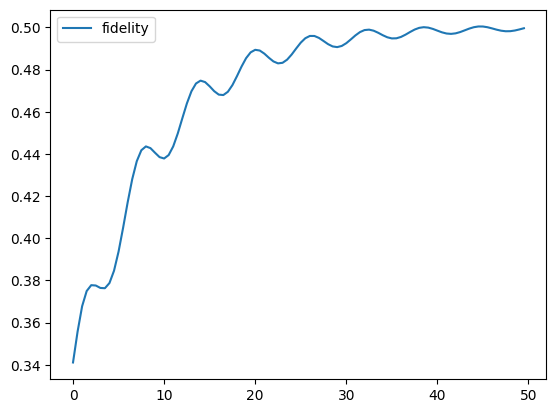

3.3885831712133685e-05


  0.0%    0 of  100 [----------------------------------------] 00:41:59

In [ ]:
fidelitys=[]
trace_distance=[]
for i,map in enumerate(map_list):

    choi_matrix=superop_to_choi(map)
    kraus_ops=choi_to_kraus(choi_matrix)

    target_unitary = np.array(-1j*op.sigma("z"), dtype=complex)  # pi rotation around x-axis

    fidelitys.append(rotation_fidelity(target_unitary,kraus_ops).real)


plt.plot(t[:-1],fidelitys,label='fidelity')
#plt.plot(t[:-1],trace_distance)
plt.legend()
plt.show()
I = np.eye(2)
residual = np.sum([K.conj().T @ K for K in kraus_ops], axis=0) - I
print(np.linalg.norm(residual))

In [ ]:
kraus_ops[0].shape

(2, 2)

 98.0%   98 of  100 [#######################################-] 00:33:19

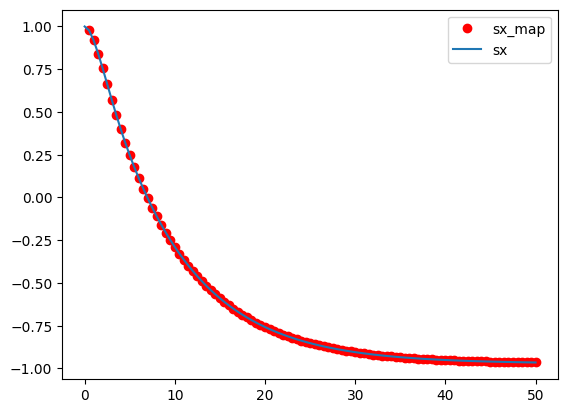

In [ ]:
sx_map=[]
sy_map=[]
sz_map=[]

sx_ad=[]
for map in map_list:
    vec_Rho=Rho_0.flatten('C')
    final_Rho=vec_Rho.T@map

    #final_Rho_a=vec_Rho.T@superoperator
    # Reshape the final state back to a density matrix
    final_Rho = final_Rho.reshape((2, 2), order='C')
    sx_ad.append(np.trace(final_Rho@op.sigma('x')).real)
    sx_map.append(np.trace(final_Rho@op.sigma('x')).real)
    sy_map.append(np.trace(final_Rho@op.sigma('y')).real)
    sz_map.append(np.trace(final_Rho@op.sigma('z')).real)

#plt.plot(t[1:],sx_ad,label='sx_ad',linestyle='dashed')
plt.plot(t[1:],sx_map,'ro',label='sx_map')
plt.plot(t,s_x,label='sx')
plt.legend()
plt.show()

100
